# DATE2 实验3：Naive Prefetch的及时性—干扰权衡

本实验对应论文C3，只比较`Static-NoPF`和`Static-NaivePF`，用于刻画传统预取的局限，
不在本实验中提前报告最终MemDomain性能。数据来自32组Window×Chunk配置。


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

roots=[Path.cwd().resolve(),Path.cwd().resolve().parent]
ROOT=next(p for p in roots if (p/'outputs/DATE2/exp3/naive_prefetch_interference.csv').exists())
DATA=ROOT/'outputs/DATE2/exp3/naive_prefetch_interference.csv'
FIG=ROOT/'fig/DATE2';FIG.mkdir(parents=True,exist_ok=True)
d=pd.read_csv(DATA)
required={'window','chunk_tiles','baseline','total_cycles','prefetch_requests',
          'prefetch_bytes','bank_conflict_count','bank_conflict_rate',
          'prefetch_interference_stall_cycles','timely_prefetch_ratio',
          'late_prefetch_ratio','unused_prefetch_ratio',
          'prefetch_occupancy_byte_cycles','compute_transfer_overlap_cycles'}
assert required.issubset(d.columns)
assert len(d)==64
assert set(d.baseline)=={'Static-NoPF','Static-NaivePF'}
assert d.groupby(['window','chunk_tiles']).size().eq(2).all()
assert sorted(d.window.unique())==[0,1,2,4,8,16,32,64]
assert sorted(d.chunk_tiles.unique())==[1,2,4,8]
pf=d[d.baseline.eq('Static-NaivePF')].merge(
    d[d.baseline.eq('Static-NoPF')],on=['window','chunk_tiles'],
    suffixes=('_pf','_nop'),validate='one_to_one')
pf['cycle_change_pct']=(pf.total_cycles_pf/pf.total_cycles_nop-1)*100
pf['conflict_change_pct']=(pf.bank_conflict_count_pf/pf.bank_conflict_count_nop-1)*100
pf['interference_stall_delta']=(
    pf.prefetch_interference_stall_cycles_pf-pf.prefetch_interference_stall_cycles_nop)
pf['occupancy_mbyte_cycles']=pf.prefetch_occupancy_byte_cycles_pf/1e6
print('Validated 32 Window×Chunk pairs')


Validated 32 Window×Chunk pairs


## 1. 性能结果：预取可以加速，也可以显著减速


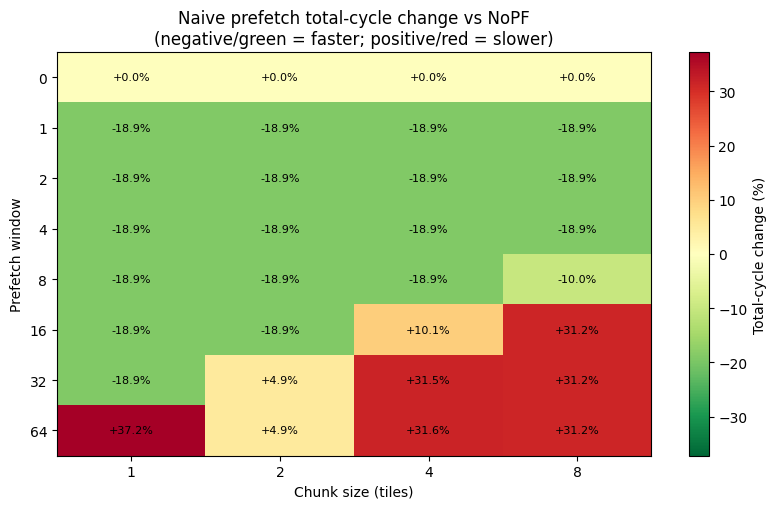

Faster configurations: 19 / 28
Slower configurations: 9 / 28
Best change: -18.92%
Worst change: +37.24%


In [8]:
perf=pf.pivot(index='window',columns='chunk_tiles',values='cycle_change_pct')
fig,ax=plt.subplots(figsize=(8.2,5.2))
limit=float(np.nanmax(np.abs(perf.to_numpy())))
im=ax.imshow(perf,aspect='auto',cmap='RdYlGn_r',
             norm=TwoSlopeNorm(vmin=-limit,vcenter=0,vmax=limit))
ax.set_xticks(range(len(perf.columns)),perf.columns)
ax.set_yticks(range(len(perf.index)),perf.index)
ax.set_xlabel('Chunk size (tiles)');ax.set_ylabel('Prefetch window')
ax.set_title('Naive prefetch total-cycle change vs NoPF\n(negative/green = faster; positive/red = slower)')
for i in range(len(perf.index)):
    for j in range(len(perf.columns)):
        ax.text(j,i,f'{perf.iloc[i,j]:+.1f}%',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,label='Total-cycle change (%)')
plt.tight_layout();plt.savefig(FIG/'exp3_performance_heatmap.pdf',bbox_inches='tight');plt.show()
active=pf[pf.window.gt(0)]
print('Faster configurations:',int(active.cycle_change_pct.lt(0).sum()),'/',len(active))
print('Slower configurations:',int(active.cycle_change_pct.gt(0).sum()),'/',len(active))
print(f'Best change: {active.cycle_change_pct.min():+.2f}%')
print(f'Worst change: {active.cycle_change_pct.max():+.2f}%')


## 2. Window过大或Chunk过大：迟到与驻留压力同时增加


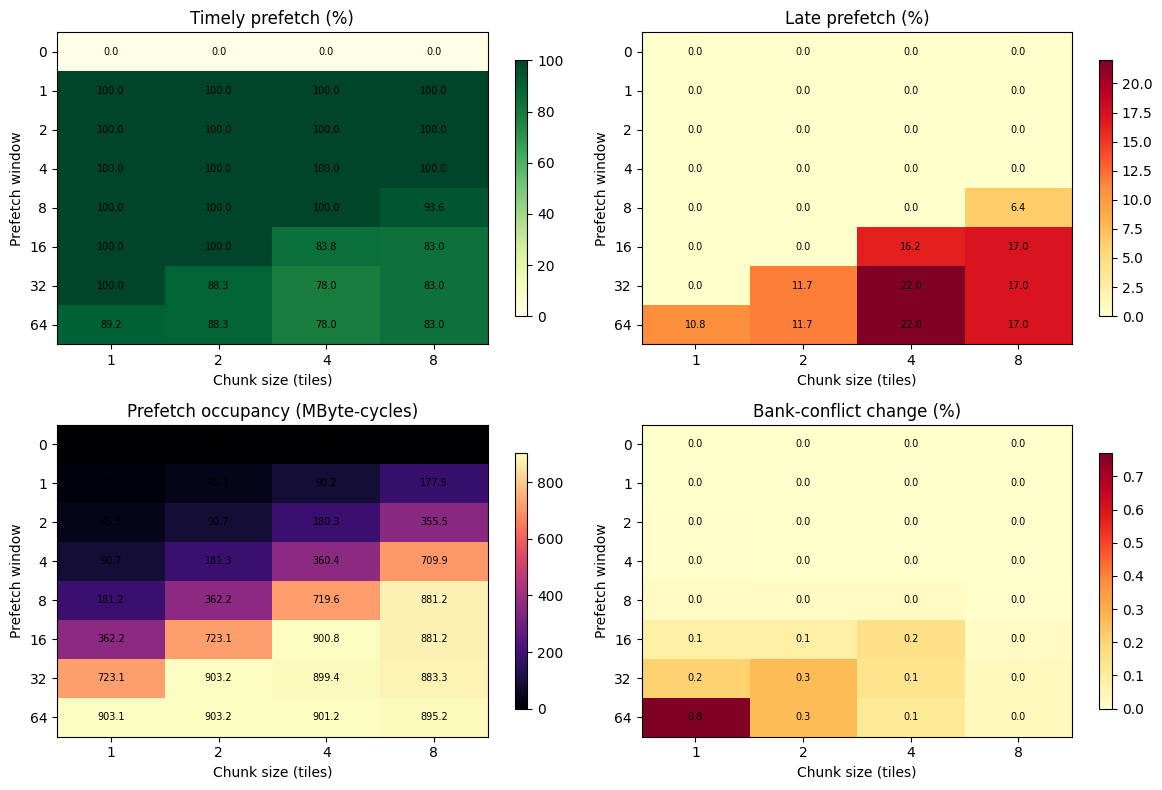

In [9]:
metrics=[
 ('timely_prefetch_ratio_pf','Timely prefetch (%)','YlGn',100),
 ('late_prefetch_ratio_pf','Late prefetch (%)','YlOrRd',100),
 ('occupancy_mbyte_cycles','Prefetch occupancy (MByte-cycles)','magma',1),
 ('conflict_change_pct','Bank-conflict change (%)','YlOrRd',1)]
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,(col,title,cmap,scale) in zip(axes.ravel(),metrics):
    p=pf.pivot(index='window',columns='chunk_tiles',values=col)*scale
    im=ax.imshow(p,aspect='auto',cmap=cmap)
    ax.set_xticks(range(len(p.columns)),p.columns);ax.set_yticks(range(len(p.index)),p.index)
    ax.set_xlabel('Chunk size (tiles)');ax.set_ylabel('Prefetch window');ax.set_title(title)
    for i in range(len(p.index)):
        for j in range(len(p.columns)):
            ax.text(j,i,f'{p.iloc[i,j]:.1f}',ha='center',va='center',fontsize=7)
    fig.colorbar(im,ax=ax,shrink=.82)
plt.tight_layout();plt.savefig(FIG/'exp3_timeliness_occupancy_conflict.pdf',bbox_inches='tight');plt.show()


## 3. 性能退化的原因与相关性


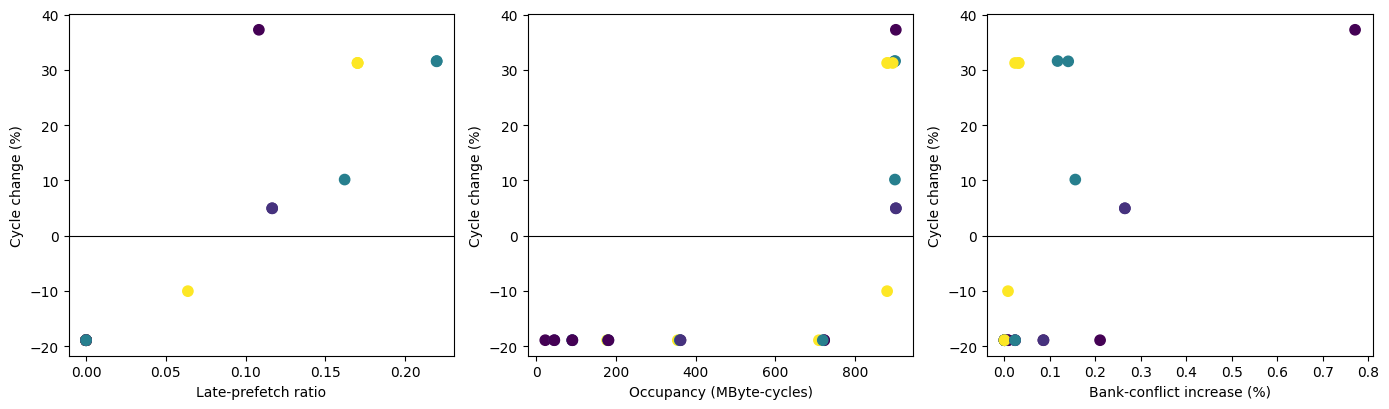

,cycle_change_pct,timely_prefetch_ratio_pf,late_prefetch_ratio_pf,occupancy_mbyte_cycles,conflict_change_pct
cycle_change_pct,1.000,-0.946,0.946,0.736,0.504
timely_prefetch_ratio_pf,-0.946,1.000,-1.000,-0.764,-0.351
late_prefetch_ratio_pf,0.946,-1.000,1.000,0.764,0.351
occupancy_mbyte_cycles,0.736,-0.764,0.764,1.000,0.490
conflict_change_pct,0.504,-0.351,0.351,0.490,1.000


In [10]:
q=pf[pf.window.gt(0)].copy()
fig,axes=plt.subplots(1,3,figsize=(14,4.2))
for ax,x,label,color in [
    (axes[0],'late_prefetch_ratio_pf','Late-prefetch ratio','#E15759'),
    (axes[1],'occupancy_mbyte_cycles','Occupancy (MByte-cycles)','#B07AA1'),
    (axes[2],'conflict_change_pct','Bank-conflict increase (%)','#F28E2B')]:
    ax.scatter(q[x],q.cycle_change_pct,c=q.chunk_tiles,cmap='viridis',s=55)
    ax.axhline(0,color='black',lw=.8);ax.set_xlabel(label);ax.set_ylabel('Cycle change (%)')
cor=q[['cycle_change_pct','timely_prefetch_ratio_pf','late_prefetch_ratio_pf',
       'occupancy_mbyte_cycles','conflict_change_pct']].corr()
plt.tight_layout();plt.savefig(FIG/'exp3_root_cause_correlation.pdf',bbox_inches='tight');plt.show()
display(cor.round(3))


## 4. 所有预取最终都被使用，仍可能伤害性能


In [11]:
used_but_slower=pf[(pf.window.gt(0))&(pf.unused_prefetch_ratio_pf.eq(0))&
                   (pf.cycle_change_pct.gt(0))].copy()
cols=['window','chunk_tiles','cycle_change_pct','timely_prefetch_ratio_pf',
      'late_prefetch_ratio_pf','occupancy_mbyte_cycles','conflict_change_pct']
display(used_but_slower[cols].sort_values('cycle_change_pct',ascending=False))
print('Unused-prefetch ratio range:',
      pf[pf.window.gt(0)].unused_prefetch_ratio_pf.min(),
      pf[pf.window.gt(0)].unused_prefetch_ratio_pf.max())
print('Used-but-slower configurations:',len(used_but_slower))
assert len(used_but_slower)>0


,window,chunk_tiles,cycle_change_pct,timely_prefetch_ratio_pf,late_prefetch_ratio_pf,occupancy_mbyte_cycles,conflict_change_pct
24,64,1,37.236157,0.891667,0.108333,903.060480,0.771028
26,64,4,31.583962,0.780220,0.219780,901.181440,0.116822
18,32,4,31.529756,0.780220,0.219780,899.358720,0.140187
27,64,8,31.232445,0.829787,0.170213,895.211520,0.031153
7,16,8,31.232445,0.829787,0.170213,881.159168,0.023364
19,32,8,31.232445,0.829787,0.170213,883.270656,0.031153
6,16,4,10.139785,0.837912,0.162088,900.813824,0.155763
17,32,2,4.940948,0.883333,0.116667,903.157760,0.264798
25,64,2,4.940948,0.883333,0.116667,903.157760,0.264798


Unused-prefetch ratio range: 0.0 0.0
Used-but-slower configurations: 9


## 5. 逐项论文契约检查


In [12]:
small_windows=pf[pf.window.isin([1,2])]
large_windows=pf[pf.window.isin([32,64])]
verdict={
 'Naive prefetch can improve performance':bool((q.cycle_change_pct<0).any()),
 'Naive prefetch can degrade performance':bool((q.cycle_change_pct>0).any()),
 'Large Window increases occupancy':bool(
     large_windows.occupancy_mbyte_cycles.mean()>small_windows.occupancy_mbyte_cycles.mean()),
 'Large Window/Chunk can become late':bool(
     pf[(pf.window>=16)&(pf.chunk_tiles>=4)].late_prefetch_ratio_pf.max()>0),
 'Used data can still interfere':bool(len(used_but_slower)>0),
 'Small Window is measurably late':bool(small_windows.late_prefetch_ratio_pf.max()>0),
 'Explicit interference-stall attribution changes':bool(
     pf.interference_stall_delta.abs().max()>0),
 'Small-Chunk control overhead is modeled':False,
}
display(pd.Series(verdict,name='supported by current data'))
assert all(verdict[k] for k in [
 'Naive prefetch can improve performance','Naive prefetch can degrade performance',
 'Large Window increases occupancy','Large Window/Chunk can become late',
 'Used data can still interfere'])


Naive prefetch can improve performance              True
Naive prefetch can degrade performance              True
Large Window increases occupancy                    True
Large Window/Chunk can become late                  True
Used data can still interfere                       True
Small Window is measurably late                    False
Explicit interference-stall attribution changes    False
Small-Chunk control overhead is modeled            False
Name: supported by current data, dtype: bool

## 实验3结论

当前数据可以证明：朴素预取并非单调有益；19/28个有效配置加速，9/28个配置减速；
大Window和大Chunk会提高驻留压力、产生迟到并造成最高约37%的退化；即使unused ratio为0，
仍有配置因时机、占用和Bank压力而变慢。

当前数据**尚不能证明**两项细节：

1. W=1–2没有出现late prefetch，因此不能写“Window太小必然来不及”；
2. 显式`prefetch_interference_stall_cycles`没有随预取变化，且架构契约忽略映射开销，
   因而不能用本实验声称“小Chunk控制开销上升”或给出直接的prefetch-induced stall数值。

这些是模型/实验覆盖缺口，不应通过改图隐藏。论文可先使用已成立的C3结论；若必须覆盖上述两项，
需要修改预取传输deadline和干扰归因模型后重跑exp3。
